In [226]:
# Lets start by importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_1samp

### Task 1: Load and Inspect the Dataset

In [2]:
# Lets load the dataset
df = pd.read_csv('updated_house_data.csv')

In [3]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,SalePrice Category
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,NaN,NaN,NaN,0,2,2008,WD,Normal,208500,Expensive
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,NaN,NaN,NaN,0,5,2007,WD,Normal,181500,Average Price
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,NaN,NaN,NaN,0,9,2008,WD,Normal,223500,Expensive
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000,Average Price
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,NaN,NaN,NaN,0,12,2008,WD,Normal,250000,Expensive


In [6]:
df.shape

(1460, 82)

In [17]:
df.dtypes

Id                      int64
MSSubClass              int64
MSZoning               object
LotFrontage           float64
LotArea                 int64
                       ...   
YrSold                  int64
SaleType               object
SaleCondition          object
SalePrice               int64
SalePrice Category     object
Length: 82, dtype: object

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 82 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Id                  1460 non-null   int64  
 1   MSSubClass          1460 non-null   int64  
 2   MSZoning            1460 non-null   object 
 3   LotFrontage         1201 non-null   float64
 4   LotArea             1460 non-null   int64  
 5   Street              1460 non-null   object 
 6   Alley               91 non-null     object 
 7   LotShape            1460 non-null   object 
 8   LandContour         1460 non-null   object 
 9   Utilities           1460 non-null   object 
 10  LotConfig           1460 non-null   object 
 11  LandSlope           1460 non-null   object 
 12  Neighborhood        1460 non-null   object 
 13  Condition1          1460 non-null   object 
 14  Condition2          1460 non-null   object 
 15  BldgType            1460 non-null   object 
 16  HouseS

##### Summary of observations:  There are alot of columns (82) in this dataset; more than we'll need. We need to subset it.
##### Also, several columns have missing data, some containing almost no values.

### Task 2: Data Wrangling and Subsetting

#### Let us subset the dataset for only relevant columns. From observing the data, we can tell which are irrelevant.

In [30]:
# We will piepeline it into a new variable
df1 = df[['Id','MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'LotShape', 'LandContour', 'Neighborhood',
    'HouseStyle', 'YearBuilt', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'GrLivArea', 'YrSold', 'SalePrice', 'SalePrice Category']]

In [40]:
df1.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,LotShape,LandContour,Neighborhood,HouseStyle,YearBuilt,TotalBsmtSF,1stFlrSF,2ndFlrSF,GrLivArea,YrSold,SalePrice,SalePrice Category
0,1,60,RL,65.0,8450,Reg,Lvl,CollgCr,2Story,2003,856,856,854,1710,2008,208500,Expensive
1,2,20,RL,80.0,9600,Reg,Lvl,Veenker,1Story,1976,1262,1262,0,1262,2007,181500,Average Price
2,3,60,RL,68.0,11250,IR1,Lvl,CollgCr,2Story,2001,920,920,866,1786,2008,223500,Expensive
3,4,70,RL,60.0,9550,IR1,Lvl,Crawfor,2Story,1915,756,961,756,1717,2006,140000,Average Price
4,5,60,RL,84.0,14260,IR1,Lvl,NoRidge,2Story,2000,1145,1145,1053,2198,2008,250000,Expensive


In [33]:
# Filter for houses built after 2000 and pipeline again
df2 = df1[df1['YearBuilt'] > 2000]

#### Lets add 2 new columns. The first is TotSqFt, which will be a sum of 2 other variables. The second would be
#### PricePerSqFt, which will be the result of SalePrice/TotSqFt

In [34]:
df2['TotSqFt'] = df2['TotalBsmtSF'] + df2['GrLivArea']

C:\Users\user\AppData\Local\Temp\ipykernel_7400\535474338.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['TotSqFt'] = df2['TotalBsmtSF'] + df2['GrLivArea']


In [36]:
# check to make sure it worked properly
df2[['TotalBsmtSF', 'GrLivArea', 'TotSqFt']]

,TotalBsmtSF,GrLivArea,TotSqFt
0,856,1710,2566
2,920,1786,2706
6,1686,1694,3380
11,1175,2324,3499
13,1494,1494,2988
...,...,...,...
1444,1422,1422,2844
1451,1573,1578,3151
1452,547,1072,1619
1453,1140,1140,2280


In [41]:
# Lets create the second new column
df2['PricePerSqFt'] = df2['SalePrice'] / df2['TotSqFt']

C:\Users\user\AppData\Local\Temp\ipykernel_7400\1264540356.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['PricePerSqFt'] = df2['SalePrice'] / df2['TotSqFt']


In [42]:
# check to make sure it worked properly
df2[['TotSqFt', 'SalePrice', 'PricePerSqFt']]

,TotSqFt,SalePrice,PricePerSqFt
0,2566,208500,81.254871
2,2706,223500,82.594235
6,3380,307000,90.828402
11,3499,345000,98.599600
13,2988,279500,93.540830
...,...,...,...
1444,2844,179600,63.150492
1451,3151,287090,91.110758
1452,1619,145000,89.561458
1453,2280,84500,37.061404


### Task 3: Handling Missing Data

In [45]:
# before we proceed, lets reindex our dataframe
df2.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,LotShape,LandContour,Neighborhood,HouseStyle,YearBuilt,TotalBsmtSF,1stFlrSF,2ndFlrSF,GrLivArea,YrSold,SalePrice,SalePrice Category,TotSqFt,PricePerSqFt
0,1,60,RL,65.0,8450,Reg,Lvl,CollgCr,2Story,2003,856,856,854,1710,2008,208500,Expensive,2566,81.254871
2,3,60,RL,68.0,11250,IR1,Lvl,CollgCr,2Story,2001,920,920,866,1786,2008,223500,Expensive,2706,82.594235
6,7,20,RL,75.0,10084,Reg,Lvl,Somerst,1Story,2004,1686,1694,0,1694,2007,307000,Expensive,3380,90.828402
11,12,60,RL,85.0,11924,IR1,Lvl,NridgHt,2Story,2005,1175,1182,1142,2324,2006,345000,Expensive,3499,98.599600
13,14,20,RL,91.0,10652,IR1,Lvl,CollgCr,1Story,2006,1494,1494,0,1494,2007,279500,Expensive,2988,93.540830


In [50]:
df2 = df2.reset_index()

In [51]:
df2.head()

,index,Id,MSSubClass,MSZoning,LotFrontage,LotArea,LotShape,LandContour,Neighborhood,HouseStyle,YearBuilt,TotalBsmtSF,1stFlrSF,2ndFlrSF,GrLivArea,YrSold,SalePrice,SalePrice Category,TotSqFt,PricePerSqFt
0,0,1,60,RL,65.0,8450,Reg,Lvl,CollgCr,2Story,2003,856,856,854,1710,2008,208500,Expensive,2566,81.254871
1,2,3,60,RL,68.0,11250,IR1,Lvl,CollgCr,2Story,2001,920,920,866,1786,2008,223500,Expensive,2706,82.594235
2,6,7,20,RL,75.0,10084,Reg,Lvl,Somerst,1Story,2004,1686,1694,0,1694,2007,307000,Expensive,3380,90.828402
3,11,12,60,RL,85.0,11924,IR1,Lvl,NridgHt,2Story,2005,1175,1182,1142,2324,2006,345000,Expensive,3499,98.599600
4,13,14,20,RL,91.0,10652,IR1,Lvl,CollgCr,1Story,2006,1494,1494,0,1494,2007,279500,Expensive,2988,93.540830


#### Now that we've reindexed our dataframe, lets check how much missing data we have in df2

In [57]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 364 entries, 0 to 363
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   index               364 non-null    int64  
 1   Id                  364 non-null    int64  
 2   MSSubClass          364 non-null    int64  
 3   MSZoning            364 non-null    object 
 4   LotFrontage         332 non-null    float64
 5   LotArea             364 non-null    int64  
 6   LotShape            364 non-null    object 
 7   LandContour         364 non-null    object 
 8   Neighborhood        364 non-null    object 
 9   HouseStyle          364 non-null    object 
 10  YearBuilt           364 non-null    int64  
 11  TotalBsmtSF         364 non-null    int64  
 12  1stFlrSF            364 non-null    int64  
 13  2ndFlrSF            364 non-null    int64  
 14  GrLivArea           364 non-null    int64  
 15  YrSold              364 non-null    int64  
 16  SalePric

In [53]:
# It appears that only one column (LotFrontage) has missing data

In [60]:
df2['LotFrontage'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 364 entries, 0 to 363
Series name: LotFrontage
Non-Null Count  Dtype  
--------------  -----  
332 non-null    float64
dtypes: float64(1)
memory usage: 3.0 KB


In [66]:
# 32 rows of missing data are present
df2['LotFrontage'].isnull().sum()

np.int64(32)

In [68]:
# NaN is present at index 357
df2['LotFrontage'].tail(10)

354    37.0
355    60.0
356    96.0
357     NaN
358    85.0
359    63.0
360    78.0
361    35.0
362    90.0
363    62.0
Name: LotFrontage, dtype: float64

In [72]:
# What is the median of LotFrontage?
df2['LotFrontage'].median()

72.0

In [75]:
# Lets replace NaN with median (72)
df2['LotFrontage'].fillna(df2['LotFrontage'].median(), inplace=True)

In [76]:
# NaN has now been replaced by 72, the median
df2['LotFrontage'].tail(10)

354    37.0
355    60.0
356    96.0
357    72.0
358    85.0
359    63.0
360    78.0
361    35.0
362    90.0
363    62.0
Name: LotFrontage, dtype: float64

#### Since there is no categorical missing data in df2, lets use df to demostrate replacement of categorical missing data

In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 82 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Id                  1460 non-null   int64  
 1   MSSubClass          1460 non-null   int64  
 2   MSZoning            1460 non-null   object 
 3   LotFrontage         1201 non-null   float64
 4   LotArea             1460 non-null   int64  
 5   Street              1460 non-null   object 
 6   Alley               91 non-null     object 
 7   LotShape            1460 non-null   object 
 8   LandContour         1460 non-null   object 
 9   Utilities           1460 non-null   object 
 10  LotConfig           1460 non-null   object 
 11  LandSlope           1460 non-null   object 
 12  Neighborhood        1460 non-null   object 
 13  Condition1          1460 non-null   object 
 14  Condition2          1460 non-null   object 
 15  BldgType            1460 non-null   object 
 16  HouseS

In [84]:
# There are 2 Nan at indexes 1450 and 1453
df['GarageFinish'].tail(10)

1450    NaN
1451    Fin
1452    Fin
1453    NaN
1454    RFn
1455    RFn
1456    Unf
1457    RFn
1458    Unf
1459    Fin
Name: GarageFinish, dtype: object

In [100]:
# Lets find the mode of GarageFinish
df['GarageFinish'].mode()

0    Unf
Name: GarageFinish, dtype: object

In [103]:
# Lets replace the missing values with the mode (UnF)
df['GarageFinish'].fillna('Unf', inplace=True)

In [105]:
# Missing values have now been replaced with Unf
df['GarageFinish'].tail(10)

1450    Unf
1451    Fin
1452    Fin
1453    Unf
1454    RFn
1455    RFn
1456    Unf
1457    RFn
1458    Unf
1459    Fin
Name: GarageFinish, dtype: object

### Task 4: Statistical Imputation for Outliers

In [107]:
df2. info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 364 entries, 0 to 363
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   index               364 non-null    int64  
 1   Id                  364 non-null    int64  
 2   MSSubClass          364 non-null    int64  
 3   MSZoning            364 non-null    object 
 4   LotFrontage         364 non-null    float64
 5   LotArea             364 non-null    int64  
 6   LotShape            364 non-null    object 
 7   LandContour         364 non-null    object 
 8   Neighborhood        364 non-null    object 
 9   HouseStyle          364 non-null    object 
 10  YearBuilt           364 non-null    int64  
 11  TotalBsmtSF         364 non-null    int64  
 12  1stFlrSF            364 non-null    int64  
 13  2ndFlrSF            364 non-null    int64  
 14  GrLivArea           364 non-null    int64  
 15  YrSold              364 non-null    int64  
 16  SalePric

#### Let's use the IQR method to detect outliers in the column TotSqFt
#### These are the steps we'll take: first, find the Q1 and Q3 quartiles, 
#### second, get the IQR
#### third, find the rows that fall outside Q1 - (1.5 * IQR) or Q3 + (1.5 * IQR)

In [111]:
# Find Q1
print(df2.TotSqFt.quantile(0.25))

2521.25


In [118]:
Q1 = df2.TotSqFt.quantile(0.25)

In [112]:
# Find Q3
print(df2.TotSqFt.quantile(0.75))

3398.0


In [119]:
Q3 = df2.TotSqFt.quantile(0.75)

In [115]:
# Get the interquartile range (IQR)
print(df2.TotSqFt.quantile(0.75) - df2.TotSqFt.quantile(0.25))

876.75


In [116]:
IQR = df2.TotSqFt.quantile(0.75) - df2.TotSqFt.quantile(0.25)

In [128]:
# Let's find our outliers
df2[(df2['TotSqFt'] < (Q1 - 1.5*IQR)) | (df2['TotSqFt'] > (Q3 + 1.5*IQR))]

,index,Id,MSSubClass,MSZoning,LotFrontage,LotArea,LotShape,LandContour,Neighborhood,HouseStyle,YearBuilt,TotalBsmtSF,1stFlrSF,2ndFlrSF,GrLivArea,YrSold,SalePrice,SalePrice Category,TotSqFt,PricePerSqFt
57,224,225,20,RL,103.0,13472,Reg,Lvl,NridgHt,1Story,2003,2392,2392,0,2392,2009,386250,Expensive,4784,80.737876
85,332,333,20,RL,85.0,10655,IR1,Lvl,NridgHt,1Story,2003,3206,1629,0,1629,2009,284000,Expensive,4835,58.738366
110,440,441,20,RL,105.0,15431,Reg,Lvl,NridgHt,1Story,2008,3094,2402,0,2402,2009,555000,Expensive,5496,100.982533
118,477,478,60,RL,105.0,13693,Reg,Lvl,NridgHt,2Story,2006,2153,2069,574,2643,2007,380000,Expensive,4796,79.232694
127,523,524,60,RL,130.0,40094,IR1,Bnk,Edwards,2Story,2007,3138,3138,1538,4676,2007,184750,Average Price,7814,23.643460
190,769,770,60,RL,47.0,53504,IR2,HLS,StoneBr,2Story,2003,1650,1690,1589,3279,2010,538000,Expensive,4929,109.149929
197,798,799,60,RL,104.0,13518,Reg,Lvl,NridgHt,2Story,2008,1926,1966,1174,3140,2009,485000,Expensive,5066,95.736281
263,1046,1047,60,RL,85.0,16056,IR1,Lvl,StoneBr,2Story,2005,1992,1992,876,2868,2006,556581,Expensive,4860,114.522840
318,1298,1299,60,RL,313.0,63887,IR3,Bnk,Edwards,2Story,2008,6110,4692,950,5642,2008,160000,Average Price,11752,13.614704
340,1373,1374,20,RL,72.0,11400,Reg,Lvl,NoRidge,1Story,2001,2633,2633,0,2633,2007,466500,Expensive,5266,88.587163


##### Visualize outliers in TotSqFt column using boxplot

{'whiskers': [<matplotlib.lines.Line2D at 0x1eca1cce5d0>,
 'caps': [<matplotlib.lines.Line2D at 0x1eca1cce850>,
 'boxes': [<matplotlib.lines.Line2D at 0x1eca1cce490>],
 'medians': [<matplotlib.lines.Line2D at 0x1eca1ccead0>],
 'fliers': [<matplotlib.lines.Line2D at 0x1eca1ccec10>],
 'means': []}

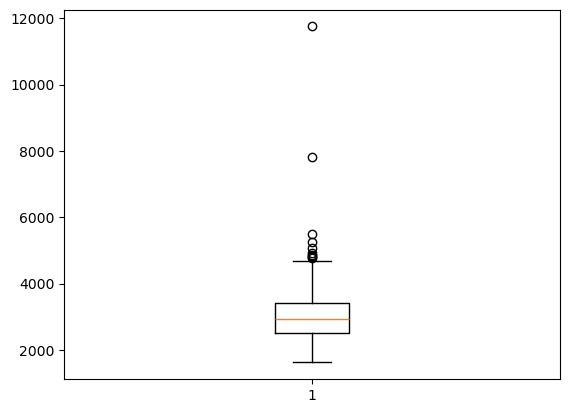

In [138]:
plt.boxplot(df2['TotSqFt'])

##### As we can see, the outliers present are quite far off from the median and Q3. Let us remove them

In [141]:
# Remove outliers and pipeline
indices_to_drop = df2[(df2['TotSqFt'] < (Q1 - 1.5*IQR)) | (df2['TotSqFt'] > (Q3 + 1.5*IQR))].index
df3 = df2.drop(indices_to_drop)

##### Outliers have now been dropped. Let us reindex df3 and then view a boxplot

In [142]:
df3 = df3.reset_index()

{'whiskers': [<matplotlib.lines.Line2D at 0x1eca1bf0550>,
 'caps': [<matplotlib.lines.Line2D at 0x1eca1bf07d0>,
 'boxes': [<matplotlib.lines.Line2D at 0x1eca1bf0410>],
 'medians': [<matplotlib.lines.Line2D at 0x1eca1bf0a50>],
 'fliers': [<matplotlib.lines.Line2D at 0x1eca1bf0b90>],
 'means': []}

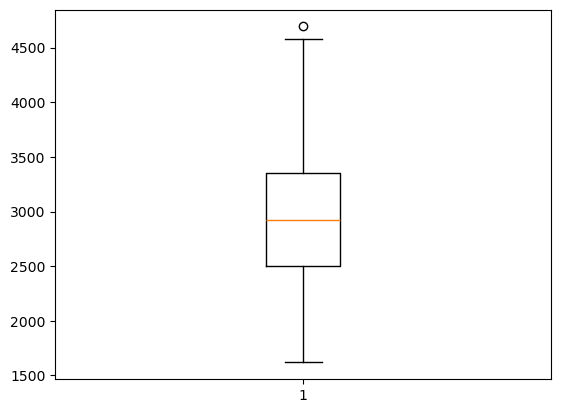

In [143]:
plt.boxplot(df3['TotSqFt'])

##### Dropping these outliers is beneficial because they would have likely caused trouble during the further analysis we will be performing

### Task 5: Exploratory Data Analysis

##### Let us make a histogram, boxplot and scatterplot of SalePrice and see what insights we'll find

(array([  6.,  94., 119.,  64.,  35.,  21.,  11.,   2.,   0.,   2.]),
 array([ 84500. , 137215.7, 189931.4, 242647.1, 295362.8, 348078.5,
        400794.2, 453509.9, 506225.6, 558941.3, 611657. ]),
 <BarContainer object of 10 artists>)

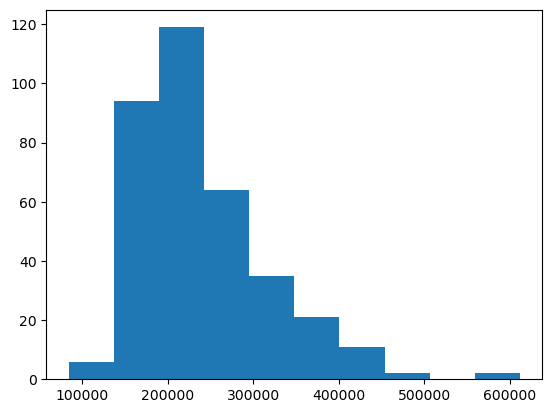

In [144]:
# Histogram of SalePrice
plt.hist(df3['SalePrice'], bins = 10)

##### Most houses were sold for between 150,000 to 300,000.
##### We also see a couple of outliers with higher sale price

{'whiskers': [<matplotlib.lines.Line2D at 0x1eca2dca990>,
 'caps': [<matplotlib.lines.Line2D at 0x1eca2dcac10>,
 'boxes': [<matplotlib.lines.Line2D at 0x1eca2dca850>],
 'medians': [<matplotlib.lines.Line2D at 0x1eca2dcae90>],
 'fliers': [<matplotlib.lines.Line2D at 0x1eca2dcafd0>],
 'means': []}

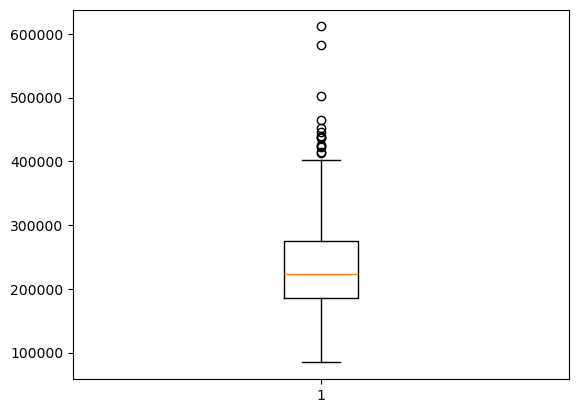

In [146]:
plt.boxplot(df3['SalePrice'])

##### There appears to be many outliers on the high side (high sale price), but no outlier on the lower side.

Text(0, 0.5, 'Total Square Feet')

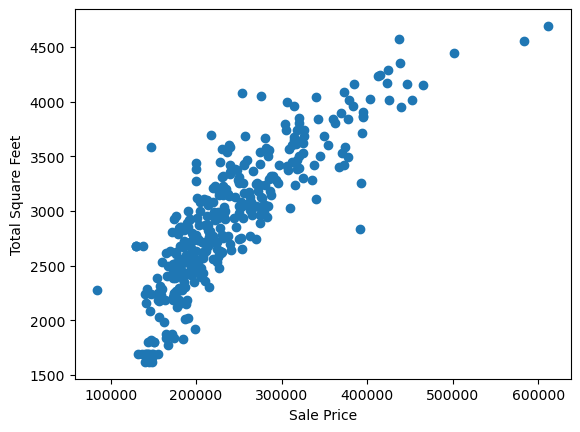

In [148]:
plt.scatter(df3['SalePrice'], df3['TotSqFt'])
plt.xlabel("Sale Price")
plt.ylabel("Total Square Feet")

##### We see a strong relationship between the size of a house and its selling price. The larger the house, hgiher the price.

##### Next, let us check what the average sale price of a house is in different neighborhoods

In [194]:
# First, we group the data by Neighborhood and aggregate on SalePrice
Neigh_prices = df3.groupby('Neighborhood')['SalePrice'].median().reset_index()

<BarContainer object of 13 artists>

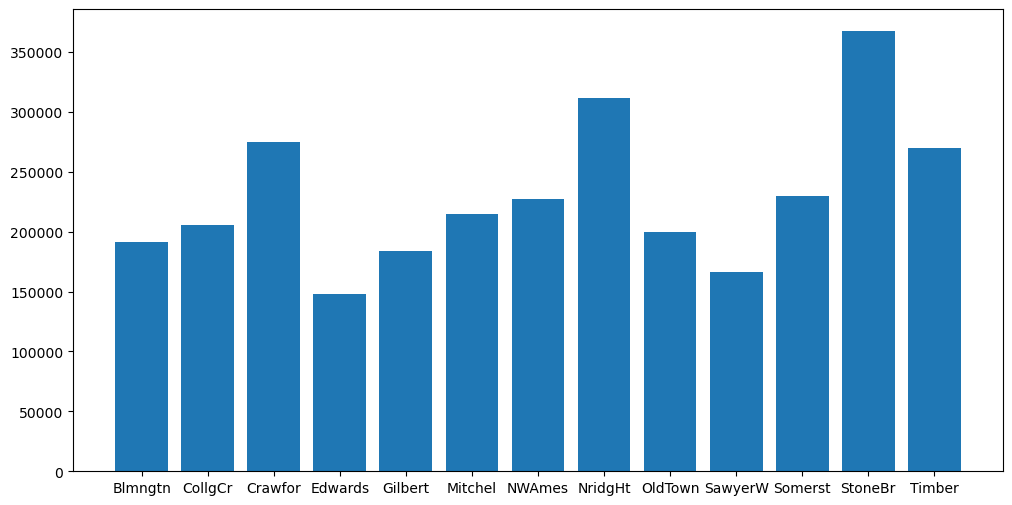

In [197]:
# Let's make the bar chart
plt.figure(figsize=(12,6))
plt.bar(Neigh_prices['Neighborhood'], Neigh_prices['SalePrice'])

##### We can see that the Neighborhood with the highest average SalePrice is StoneBr, while the least is Edwards.

### Task 6: Use NumPy

##### Let's use NumPy to randomly generate a new array for simulation

In [212]:
# Generate 5 random numbers from 0 to 9
five_random_numbers = np.random.randint(0,10,5)

In [213]:
print(five_random_numbers)

[0 3 7 9 3]


##### Now, let's use NumPy to calculate mean snd std of SalePrice column

In [222]:
# Mean
print(np.mean(df3['SalePrice']))

240146.6497175141


In [225]:
# Standard deviation
print(np.std(df3['SalePrice']))

77923.41736136054


### Task 7: Introductory Inferential Statistics

#### Null Hypothesis: the avergae price of a home is 180,000
#### Alternate Hypothesis: the average price of a home is not 180,000
#### Let's perform a t-test to test our hypothesis

In [227]:
# first make an array of our SalePrice data
data = np.array(df['SalePrice'])

In [228]:
# next specify hypothesized average
hyp_mean = 180_000

In [229]:
# Let's perfrom the t test
t_statistic, p_value = ttest_1samp(data, hyp_mean)

In [230]:
print(p_value)

0.6577784607522807


##### The p value is above the typical 0.05 threshold so we FAIL TO REJECT THE NULL HYPOTHESIS.